# Notebook 1 - Descarga, comprensión y creación del dataset

## Objetivo
Este notebook cubre los puntos 1, 2 y 3 del taller:

1. Descarga del dataset.
2. Comprensión del dataset.
3. Construcción del dataset con partición 80% entrenamiento y 20% prueba.

## Qué hace este notebook
- Descarga el dataset desde Kaggle.
- Explora su estructura.
- Construye un `DataFrame` con rutas y clases.
- Analiza clases, tamaños de imagen y distribución.
- Crea la partición estratificada 80/20.
- Guarda archivos CSV reutilizables por los notebooks de modelos.


In [ ]:
# Instalar dependencias necesarias para el taller. También se puede con uv sync:
# !pip install -q kagglehub kaggle scikit-learn pillow seaborn pandas matplotlib tensorflow


In [7]:
import os
import json
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

BASE_DIR = Path.cwd().parent
DATA_ROOT = BASE_DIR / "data"
DATA_ROOT.mkdir(exist_ok=True)

print("Directorio de trabajo:", BASE_DIR)
print("Carpeta de datos:", DATA_ROOT)


Directorio de trabajo: c:\Users\sebas\Desktop\Repositorios\1. DL\DL_Taller2
Carpeta de datos: c:\Users\sebas\Desktop\Repositorios\1. DL\DL_Taller2\data


## Descarga del dataset
El dataset del taller corresponde al recurso de Kaggle **Traffic Sign Classification and Recognition**.


In [9]:
DATASET_SLUG = "wjybuqi/traffic-sign-classification-and-recognition"
dataset_path = None

try:
    import kagglehub
    dataset_path = kagglehub.dataset_download(DATASET_SLUG)
    print("Dataset descargado con kagglehub en:", dataset_path)
except Exception as e:
    print("No fue posible descargar con kagglehub.")
    print("Detalle:", e)


Dataset descargado con kagglehub en: C:\Users\sebas\.cache\kagglehub\datasets\wjybuqi\traffic-sign-classification-and-recognition\versions\1


In [5]:
if dataset_path is None:
    try:
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
        target_dir = DATA_ROOT / "kaggle_download"
        target_dir.mkdir(parents=True, exist_ok=True)
        api.dataset_download_files(DATASET_SLUG, path=str(target_dir), unzip=True)
        dataset_path = str(target_dir)
        print("Dataset descargado con API de Kaggle en:", dataset_path)
    except Exception as e:
        print("Tampoco fue posible descargar con la API de Kaggle.")
        print("Configura tus credenciales de Kaggle y vuelve a ejecutar esta celda.")
        print("Detalle:", e)


In [10]:
if dataset_path is None:
    raise RuntimeError(
        "No se pudo descargar el dataset automáticamente. "
        "Configura credenciales de Kaggle o descarga manualmente el dataset."
    )

dataset_path = Path(dataset_path)
print("Ruta final del dataset:", dataset_path)


Ruta final del dataset: C:\Users\sebas\.cache\kagglehub\datasets\wjybuqi\traffic-sign-classification-and-recognition\versions\1


## Exploración de estructura de carpetas
Esta parte ayuda a responder:
- ¿Qué información presenta el dataset?
- ¿Cuáles son las clases?
- ¿Cómo está organizado el contenido?


In [11]:
def show_tree(root: Path, max_depth=2, max_entries=20):
    root = Path(root)
    print(f"Explorando: {root}")
    count = 0
    for path in sorted(root.rglob("*")):
        rel = path.relative_to(root)
        depth = len(rel.parts)
        if depth <= max_depth:
            print(("  " * (depth - 1)) + ("[D] " if path.is_dir() else "- ") + rel.parts[-1])
            count += 1
            if count >= max_entries:
                print("... (salida truncada)")
                break

show_tree(dataset_path, max_depth=3, max_entries=80)


Explorando: C:\Users\sebas\.cache\kagglehub\datasets\wjybuqi\traffic-sign-classification-and-recognition\versions\1
- submit_example.json
[D] test_dataset
  [D] test
    [D] GuideSign
    [D] M1
    [D] M4
    [D] M5
    [D] M6
    [D] M7
    [D] P1
    [D] P10_50
    [D] P12
    [D] W1
[D] train_dataset
  [D] train
    [D] GuideSign
    [D] M1
    [D] M4
    [D] M5
    [D] M6
    [D] M7
    [D] P1
    [D] P10_50
    [D] P12
    [D] W1
  - train.json


In [12]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".ppm"}

image_files = [p for p in dataset_path.rglob("*") if p.suffix.lower() in IMAGE_EXTS]
print("Número total de imágenes encontradas:", len(image_files))

image_files[:10]


Número total de imágenes encontradas: 6348


[WindowsPath('C:/Users/sebas/.cache/kagglehub/datasets/wjybuqi/traffic-sign-classification-and-recognition/versions/1/test_dataset/test/GuideSign/00004.jpg'),
 WindowsPath('C:/Users/sebas/.cache/kagglehub/datasets/wjybuqi/traffic-sign-classification-and-recognition/versions/1/test_dataset/test/GuideSign/00053.jpg'),
 WindowsPath('C:/Users/sebas/.cache/kagglehub/datasets/wjybuqi/traffic-sign-classification-and-recognition/versions/1/test_dataset/test/GuideSign/00055.jpg'),
 WindowsPath('C:/Users/sebas/.cache/kagglehub/datasets/wjybuqi/traffic-sign-classification-and-recognition/versions/1/test_dataset/test/GuideSign/00058.jpg'),
 WindowsPath('C:/Users/sebas/.cache/kagglehub/datasets/wjybuqi/traffic-sign-classification-and-recognition/versions/1/test_dataset/test/GuideSign/00074.jpg'),
 WindowsPath('C:/Users/sebas/.cache/kagglehub/datasets/wjybuqi/traffic-sign-classification-and-recognition/versions/1/test_dataset/test/GuideSign/00079.jpg'),
 WindowsPath('C:/Users/sebas/.cache/kagglehub/

## Construcción del inventario de imágenes
Se asume que la clase puede inferirse desde el nombre de la carpeta padre o desde alguna parte de la ruta.
La función siguiente intenta detectar automáticamente la carpeta de clase.


In [13]:
def infer_class_name(path: Path, root: Path) -> str:
    rel_parts = path.relative_to(root).parts

    # Heurística 1: usar la carpeta inmediatamente anterior al archivo
    if len(rel_parts) >= 2:
        return rel_parts[-2]
    return "unknown"

records = []
for p in image_files:
    class_name = infer_class_name(p, dataset_path)
    records.append({
        "filepath": str(p),
        "filename": p.name,
        "class_name": str(class_name)
    })

df = pd.DataFrame(records)
df.head()


,filepath,filename,class_name
0,C:\Users\sebas\.cache\kagglehub\datasets\wjybu...,00004.jpg,GuideSign
1,C:\Users\sebas\.cache\kagglehub\datasets\wjybu...,00053.jpg,GuideSign
2,C:\Users\sebas\.cache\kagglehub\datasets\wjybu...,00055.jpg,GuideSign
3,C:\Users\sebas\.cache\kagglehub\datasets\wjybu...,00058.jpg,GuideSign
4,C:\Users\sebas\.cache\kagglehub\datasets\wjybu...,00074.jpg,GuideSign


In [14]:
class_counts = (
    df["class_name"]
    .value_counts()
    .rename_axis("class_name")
    .reset_index(name="n_images")
)

print("Número de clases detectadas:", class_counts.shape[0])
display(class_counts.head(20))


Número de clases detectadas: 10


,class_name,n_images
0,M4,3375
1,GuideSign,1233
2,M7,494
3,P1,263
4,M1,261
5,M5,225
6,W1,153
7,M6,142
8,P10_50,101
9,P12,101


## Descripción del dataset
- El dataset contiene imágenes de señales de tránsito etiquetadas para un problema de clasificación supervisada.
- Cada imagen pertenece a una clase de señal de tránsito.
- Las clases están organizadas por carpetas.

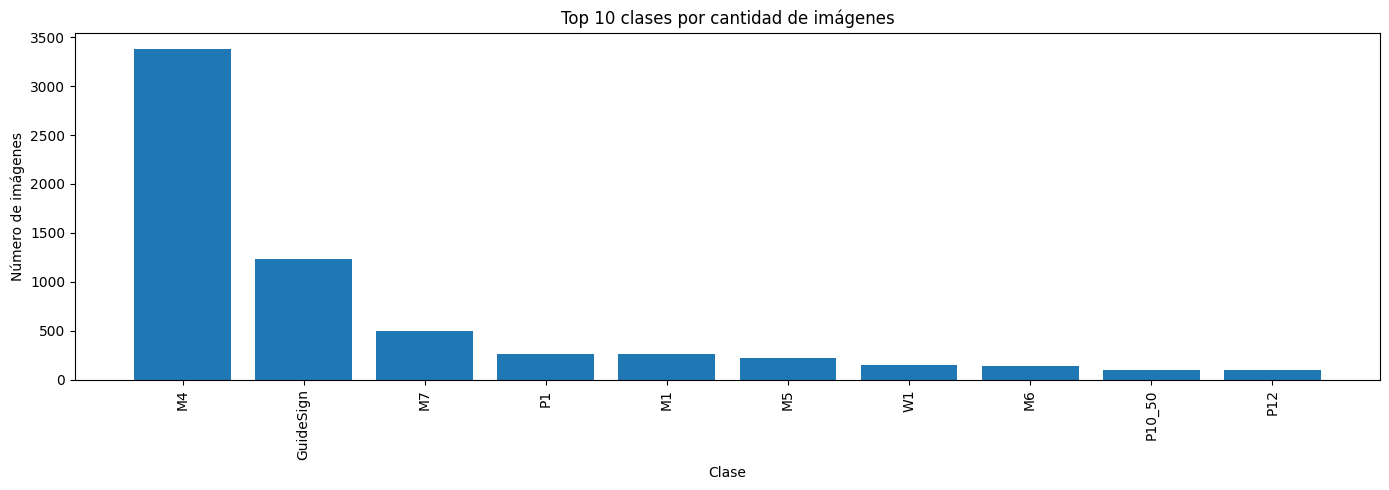

In [15]:
plt.figure(figsize=(14, 5))
top_n = min(25, len(class_counts))
plot_df = class_counts.head(top_n)
plt.bar(plot_df["class_name"].astype(str), plot_df["n_images"])
plt.xticks(rotation=90)
plt.title(f"Top {top_n} clases por cantidad de imágenes")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.tight_layout()
plt.show()


## Características de las imágenes
El taller pide describir las características de las imágenes.  
Aquí medimos dimensiones, canales y algunos ejemplos visuales.


In [16]:
sample_size = min(500, len(df))
sample_df = df.sample(sample_size, random_state=SEED).copy()

widths, heights, modes = [], [], []

for fp in sample_df["filepath"]:
    try:
        with Image.open(fp) as img:
            widths.append(img.width)
            heights.append(img.height)
            modes.append(img.mode)
    except Exception:
        widths.append(np.nan)
        heights.append(np.nan)
        modes.append("ERROR")

sample_df["width"] = widths
sample_df["height"] = heights
sample_df["mode"] = modes

display(sample_df.head())


,filepath,filename,class_name,width,height,mode
730,C:\Users\sebas\.cache\kagglehub\datasets\wjybu...,00428.jpg,GuideSign,224,224,RGB
2131,C:\Users\sebas\.cache\kagglehub\datasets\wjybu...,00406.jpg,M4,224,224,RGB
3070,C:\Users\sebas\.cache\kagglehub\datasets\wjybu...,01395.jpg,M4,224,224,RGB
6101,C:\Users\sebas\.cache\kagglehub\datasets\wjybu...,00095.jpg,P10_50,224,224,RGB
217,C:\Users\sebas\.cache\kagglehub\datasets\wjybu...,02793.jpg,M4,224,224,RGB


In [17]:
summary_dims = {
    "n_muestras_medidas": len(sample_df),
    "ancho_min": sample_df["width"].min(),
    "ancho_max": sample_df["width"].max(),
    "ancho_promedio": sample_df["width"].mean(),
    "alto_min": sample_df["height"].min(),
    "alto_max": sample_df["height"].max(),
    "alto_promedio": sample_df["height"].mean(),
    "modos_detectados": sample_df["mode"].value_counts().to_dict()
}

summary_dims


{'n_muestras_medidas': 500,
 'ancho_min': np.int64(224),
 'ancho_max': np.int64(224),
 'ancho_promedio': np.float64(224.0),
 'alto_min': np.int64(224),
 'alto_max': np.int64(224),
 'alto_promedio': np.float64(224.0),
 'modos_detectados': {'RGB': 500}}

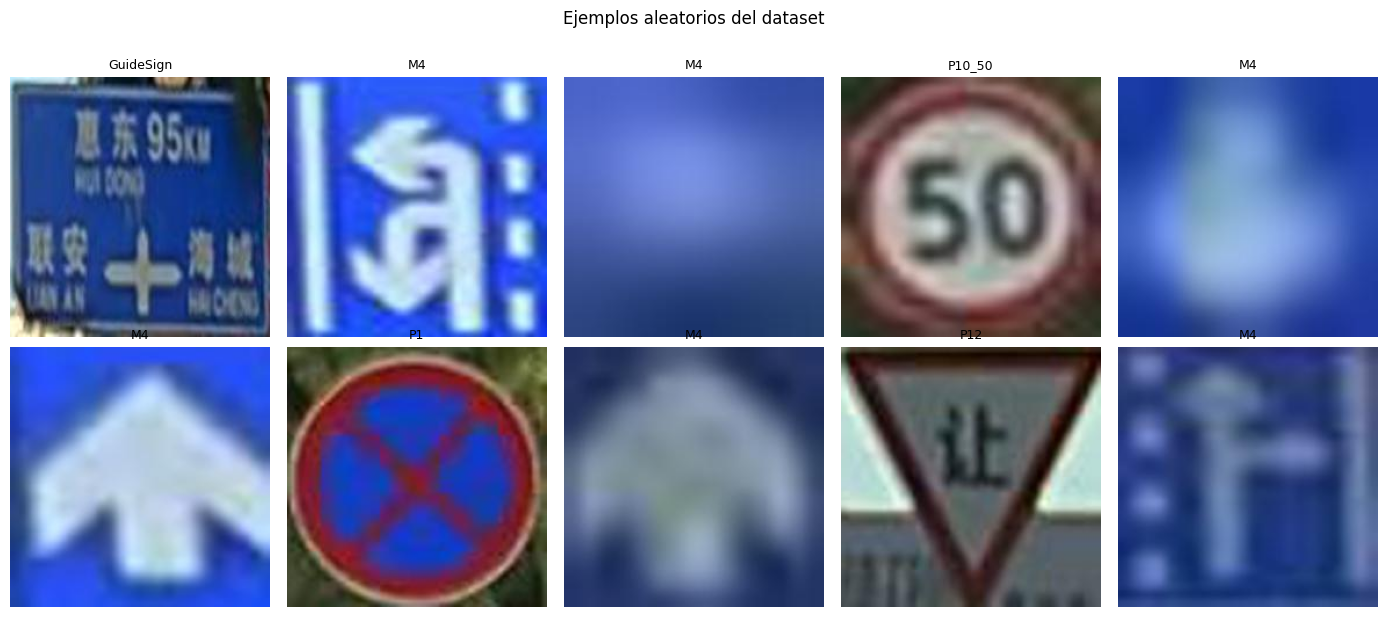

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

example_paths = df.sample(min(10, len(df)), random_state=SEED)

for ax, (_, row) in zip(axes, example_paths.iterrows()):
    with Image.open(row["filepath"]) as img:
        ax.imshow(img)
    ax.set_title(str(row["class_name"]), fontsize=9)
    ax.axis("off")

for ax in axes[len(example_paths):]:
    ax.axis("off")

plt.suptitle("Ejemplos aleatorios del dataset", y=1.02)
plt.tight_layout()
plt.show()


## Limpieza mínima y codificación de clases


In [19]:
# Eliminamos filas potencialmente problemáticas
df = df.dropna(subset=["filepath", "class_name"]).copy()
df["class_name"] = df["class_name"].astype(str)

# Codificación
classes = sorted(df["class_name"].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

df["label"] = df["class_name"].map(class_to_idx)

print("Número final de clases:", len(classes))
print("Primeras clases:", classes[:10])


Número final de clases: 10
Primeras clases: ['GuideSign', 'M1', 'M4', 'M5', 'M6', 'M7', 'P1', 'P10_50', 'P12', 'W1']


## Partición 80/20 de entrenamiento y pruebas
El taller pide construir el dataset con:

- 80% entrenamiento
- 20% prueba

Se usa **partición estratificada** para conservar aproximadamente la proporción de clases.


In [20]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Tamaño entrenamiento:", train_df.shape)
print("Tamaño prueba:", test_df.shape)


Tamaño entrenamiento: (5078, 4)
Tamaño prueba: (1270, 4)


In [21]:
split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "n_samples": [len(train_df), len(test_df)],
    "percentage": [len(train_df)/len(df), len(test_df)/len(df)]
})

display(split_summary)


,split,n_samples,percentage
0,train,5078,0.799937
1,test,1270,0.200063


In [22]:
# Verificación rápida de proporciones por clase
train_dist = train_df["class_name"].value_counts(normalize=True).rename("train_prop")
test_dist = test_df["class_name"].value_counts(normalize=True).rename("test_prop")
dist_compare = pd.concat([train_dist, test_dist], axis=1).fillna(0).reset_index().rename(columns={"index": "class_name"})
display(dist_compare.head(20))


,class_name,train_prop,test_prop
0,M4,0.531705,0.531496
1,GuideSign,0.194171,0.194488
2,M7,0.077787,0.077953
3,P1,0.041355,0.041732
4,M1,0.041158,0.040945
5,M5,0.035447,0.035433
6,W1,0.024025,0.024409
7,M6,0.022450,0.022047
8,P10_50,0.015951,0.015748
9,P12,0.015951,0.015748


## Guardado de artefactos para los demás notebooks
Se guardan:
- `train_split.csv`
- `test_split.csv`
- `class_mapping.json`
- `dataset_summary.json`


In [24]:
artifacts_dir = DATA_ROOT / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(artifacts_dir / "train_split.csv", index=False)
test_df.to_csv(artifacts_dir / "test_split.csv", index=False)

def to_jsonable(obj):
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj).__name__} is not JSON serializable")

with open(artifacts_dir / "class_mapping.json", "w", encoding="utf-8") as f:
    json.dump({
        "classes": classes,
        "class_to_idx": class_to_idx,
        "idx_to_class": {str(k): v for k, v in idx_to_class.items()}
    }, f, ensure_ascii=False, indent=2, default=to_jsonable)

with open(artifacts_dir / "dataset_summary.json", "w", encoding="utf-8") as f:
    json.dump({
        "n_total_images": int(len(df)),
        "n_classes": int(len(classes)),
        "train_size": int(len(train_df)),
        "test_size": int(len(test_df)),
        "image_dim_summary": summary_dims
    }, f, ensure_ascii=False, indent=2, default=to_jsonable)

print("Archivos guardados en:", artifacts_dir)
print(list(artifacts_dir.iterdir()))


Archivos guardados en: c:\Users\sebas\Desktop\Repositorios\1. DL\DL_Taller2\data\artifacts
[WindowsPath('c:/Users/sebas/Desktop/Repositorios/1. DL/DL_Taller2/data/artifacts/class_mapping.json'), WindowsPath('c:/Users/sebas/Desktop/Repositorios/1. DL/DL_Taller2/data/artifacts/dataset_summary.json'), WindowsPath('c:/Users/sebas/Desktop/Repositorios/1. DL/DL_Taller2/data/artifacts/test_split.csv'), WindowsPath('c:/Users/sebas/Desktop/Repositorios/1. DL/DL_Taller2/data/artifacts/train_split.csv')]
